<h1> Beamforming</h1>

In [261]:
#import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
from scipy.signal import convolve2d
import time
#import open3d as o3d
import utils

from streaming.gtrack.config import Detection

In [497]:
def beamform_2d_s(beat_freq_data, phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_locs, z_locs, r_idxs, radar_params, index, dets):
    """
    Performs 2D beamforming along the azimuth (horizontal) dimension, this results in a bird eye view image.
    - beat_freq_data: beat data AKA the range FFT (size: num_x_stps * num_z_stps * num TX * num RX, num ADC samples)
    - phi_s: first azimuth angle that you want to start computing
    - phi_e: last azimuth angle that you want to compute
    - phi_res: resolution of the azimuth angles you want to compute
    - theta_s: first elevation angle that you want to start computing
    - theta_e: last elevation angle that you want to compute
    - theta_res: resolution of the elevation angles you want to compute
    - x_locs: x coordinate of antenna locations
    - z_locs: z coordinate of antenna locations
    - r_idx: range bins to calculate
    - radar_parms: radar_params if needed

    Returns:
    - sph_pwr: beamformed result (size: n_phi, n_theta, n_range)
    - phi: array of azimuth angles
    - theta: array of elevation angles
    """

    # Radar parameters
    lm = radar_params["lm"]
    fs       = radar_params["sample_rate"]  # [Hz]
    num_samps= radar_params["num_samples"]  # ADC samples per chirp
    N_dop    = 16                           # chirps per frame
    lam      = radar_params["lm"]           # wavelength [m]

    ## Compute velocity resolution
    # 1) chirp duration (neglecting idle time)
    T_chirp = num_samps / fs                # [s]

    # 2) PRF
    PRF     = 1.0 / T_chirp                 # [Hz]

    # 3) velocity‐resolution
    vel_res = lam/2 * PRF / N_dop           # [m/s per Doppler bin]



    # Convert angles to radians
    phi = np.arange(phi_s, phi_e, phi_res) * np.pi / 180
    num_phi = len(phi)

    angles = x_locs * np.cos(phi[:, np.newaxis])
    phase_shifts = np.exp((1j * 2 * np.pi / lm) * angles)

    # Initialize output
    sph_pwr = np.zeros((num_phi, r_idxs.shape[0]), dtype=np.complex64)

    r_idx, d_idx = np.nonzero(dets)

    detections = []

    for d, r in zip(r_idx, d_idx):

        beat = beat_freq_data[:, d, r]
        beamformed_signal = beat[np.newaxis, :] * phase_shifts
        sph_pwr[:, r] = np.maximum(sph_pwr[:, r], np.abs(np.sum(beamformed_signal, axis=-1)))

        snr = np.abs(np.sum(beamformed_signal, axis=-1)) ## rajouter variance? #shape (num_phi)

        rang = np.repeat(r, num_phi)
        v = (d - N_dop/2) * vel_res
        v_all = np.repeat(v, num_phi)

        small_detection = [
        Detection(r_m, az, v, snr)
        for r_m, az, v, snr in zip(rang, phi, v_all, snr)
        ]

        detections.extend(small_detection)

    return sph_pwr, detections

In [498]:
def cfar_ca_2d(power_map,
               num_train_range: int = 10,
               num_train_doppler: int = 8,
               num_guard_range: int = 2,
               num_guard_doppler: int = 2,
               rate_fa: float = 1e-3):
    """
    2D Cell-Averaging CFAR on a (range × Doppler) power map.

    Parameters
    ----------
    power_map : 2D np.ndarray
        The incoherent power map |X|^2 over (range, Doppler).
    num_train_range : int
        # of training cells on each side in range
    num_train_doppler : int
        # of training cells on each side in Doppler
    num_guard_range : int
        # of guard cells on each side in range
    num_guard_doppler : int
        # of guard cells on each side in Doppler
    rate_fa : float
        Desired probability of false alarm

    Returns
    -------
    detection_map : 2D bool np.ndarray
        True where power_map exceeds the CFAR threshold.
    """
    Tr, Td = num_train_range, num_train_doppler
    Gr, Gd = num_guard_range, num_guard_doppler

    # full window half–sizes
    Wr = Tr + Gr
    Wd = Td + Gd

    # number of training cells total
    Nwin = (2*Wr+1)*(2*Wd+1)
    Nguard = (2*Gr+1)*(2*Gd+1)
    Ntrain = Nwin - Nguard

    # build convolution kernels
    kernel_win   = np.ones((2*Wr+1, 2*Wd+1), dtype=float)
    kernel_guard = np.ones((2*Gr+1,2*Gd+1), dtype=float)

    # sum over full window
    sum_win   = convolve2d(power_map, kernel_win,   mode='same', boundary='fill', fillvalue=0)
    # sum over guard+CUT region
    sum_guard = convolve2d(power_map, kernel_guard, mode='same', boundary='fill', fillvalue=0)

    # training‐cell sum = window minus guard (which includes the CUT)
    sum_train = sum_win - sum_guard

    # noise estimate (average of training cells)
    noise_level = sum_train / float(Ntrain)

    # CFAR threshold multiplier (cell–averaging formula)
    alpha = Ntrain * (rate_fa**(-1.0/Ntrain) - 1.0)
    threshold = alpha * noise_level

    # detection mask
    return power_map > threshold

In [499]:
def process_frame(raw_data, cfar_params):
    """
    Full pipeline for one frame:
      raw_data : np.array, shape (N_ant, N_adc, N_chirps)
      radar_params : dict with at least "fc" (Hz)
      x_locs, z_locs : 1D arrays of antenna x,z positions (meters)
      phi_*, theta_* : angle scan bounds/resolution (degrees)
      cfar_params : dict with keys
        num_train_r, num_train_d,
        num_guard_r, num_guard_d,
        threshold_scale

    returns
        dets : list of (r_idx, d_idx) tuples
    """
    N_ant, N_adc, N_chirps = raw_data.shape

    # 1) Range FFT
    rng_ffted = np.fft.fft(raw_data, axis=2)   # → (N_ant, N_adc, N_R=N_chirps)

    # 2) Doppler FFT
    rd_cube = np.fft.fft(rng_ffted, axis=1)    # → (N_ant, N_D=N_adc, N_R=N_chirps)

    # 3) Build RD magnitude for CFAR (average across antennas)
    rd_map = np.mean(np.abs(rd_cube)**2, axis=0)  # shape (N_R, N_D)

    # 4) CFAR detections
    dets = cfar_ca_2d(rd_map,
                    cfar_params["num_train_r"],
                    cfar_params["num_train_d"],
                    cfar_params["num_guard_r"],
                    cfar_params["num_guard_d"],
                    cfar_params["threshold_scale"])



    return dets

Load data.

In [500]:
# Define the path to the data
data_path = ('/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/project/data/input/data_bin/rdc_data_00000.mat')

# Static data path
static_data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/project/data/input/data_mat/project/rdc_vide.mat'

# Define the path to save the data
save_data_path = ('/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/project/data/output/project/beamforming_2d_output/rdc_1')

# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp x num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples'
"""

radar_params, raw_data = utils.load_raw_data(data_path)

In [501]:
print(raw_data.shape)
print(radar_params)

(192, 250, 576)
{'sample_rate': 10000000.0, 'num_samples': 576, 'slope': 70150000000000.0, 'lm': 0.003896103896103896, 'num_x_stp': 192, 'num_z_stp': 250, 'num_tx': 48, 'num_rx': 4, 'adc_samples': 576, 'num_frames': 250}


In [502]:
raw_data = raw_data.reshape(12, 16, 250, 576)
raw_data = raw_data[:,:,0,:]
print(raw_data.shape)

(12, 16, 576)


In [503]:
dets = process_frame(raw_data[:,:,0:140], {
    "num_train_r": 12,
    "num_train_d": 10,
    "num_guard_r": 3,
    "num_guard_d": 3,
    "threshold_scale": 1e-1
})

In [504]:
print(dets.shape)
print(dets[0])

(16, 140)
[ True False False False False False  True  True  True False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False  True
  True  True  True  True False False False False False False False False
 False False False False False  True  True False False False False False
 False False False  True False False False False False False False False
 False False False False False  True  True False False False False False
 False False False  True False False False False False False False False
 False False False False False False False False False  True  True  True
  True  True  True  True False False False False False False False False
 False False False False False False False False False False False  True
  True  True  True  True False False False False]


In [505]:
r_idx, d_idx = np.nonzero(dets)
print(r_idx.size)
print(d_idx.size)
a = zip(r_idx, d_idx)
l = 0
for j,i in zip(r_idx, d_idx):
    print(i,j)
    l += 1

print(l)

462
462
0 0
6 0
7 0
8 0
35 0
36 0
37 0
38 0
39 0
53 0
54 0
63 0
77 0
78 0
87 0
105 0
106 0
107 0
108 0
109 0
110 0
111 0
131 0
132 0
133 0
134 0
135 0
0 1
1 1
6 1
7 1
8 1
16 1
17 1
35 1
36 1
37 1
38 1
39 1
53 1
54 1
63 1
71 1
77 1
78 1
86 1
87 1
106 1
107 1
108 1
130 1
131 1
132 1
133 1
134 1
135 1
136 1
0 2
6 2
7 2
8 2
16 2
17 2
36 2
37 2
38 2
40 2
53 2
54 2
63 2
64 2
70 2
71 2
77 2
85 2
86 2
87 2
88 2
93 2
106 2
107 2
108 2
131 2
132 2
133 2
134 2
135 2
136 2
6 3
7 3
8 3
35 3
36 3
37 3
38 3
39 3
53 3
54 3
63 3
64 3
76 3
77 3
78 3
86 3
87 3
106 3
107 3
108 3
109 3
131 3
132 3
133 3
134 3
135 3
136 3
0 4
7 4
16 4
17 4
18 4
36 4
37 4
38 4
39 4
53 4
54 4
63 4
64 4
76 4
77 4
78 4
86 4
87 4
88 4
106 4
107 4
108 4
109 4
122 4
132 4
133 4
134 4
0 5
1 5
6 5
7 5
8 5
16 5
17 5
18 5
35 5
36 5
37 5
38 5
39 5
40 5
41 5
52 5
53 5
54 5
55 5
63 5
70 5
76 5
77 5
78 5
85 5
86 5
87 5
88 5
89 5
106 5
107 5
109 5
110 5
111 5
112 5
132 5
133 5
134 5
139 5
6 6
7 6
8 6
16 6
17 6
18 6
36 6
37 6
38 6
39 6
40 6

Defining antenna positions. 

In [506]:
x_ant_pos, z_pos, x_ant = utils.get_ant_pos_2d(12, 250, 4) # this returns x position of rx, z positions of rx and tx, and x position of tx

In [524]:
dets = process_frame(raw_data[:,:,0:140], {
    "num_train_r": 10,
    "num_train_d": 8,
    "num_guard_r": 2,
    "num_guard_d": 2,
    "threshold_scale": 1e-7
})

sph_pwr, detections = beamform_2d_s(raw_data[:,:,0:140], 0, 180, 1, 70, 110, 1, x_ant_pos[:,0], z_pos, np.arange(0, 140), radar_params, 0, dets)

In [525]:
from streaming.gtrack.config import GTrackConfig2D
from streaming.gtrack.module import GTrackModule2D

cfg = GTrackConfig2D(
    max_points           = 100,          # max detections per frame
    max_tracks           = 10,           # max simultaneous tracks
    dt                   = 0.1,          # time between frames (s)
    process_noise        = 0.1,          # Q spectral density
    meas_noise_range     = 1.0,          # σ² range noise (m²)
    meas_noise_az        = 0.01,         # σ² azimuth noise (rad²)
    gating_threshold     = 9.21,         # ≈95% gate for 2-DOF chi²
    alloc_range_gate     = 0.5,          # cluster gate (m)
    alloc_az_gate        = 0.05,         # cluster gate (rad)
    alloc_vel_gate       = 0.5,          # cluster gate (m/s)
    min_cluster_points   = 1,            # you can increase if you want multi-point seeds
    alloc_snr_threshold  = 5.0,          # sum-SNR threshold
    init_state_cov       = 100.0,        # starting P for new tracks
    det_to_active_count  = 2,            # hits needed to go ACTIVE
    det_to_free_count    = 2,            # misses to drop DETECTION
    act_to_free_count    = 3,            # misses to drop ACTIVE
    presence_zones       = [],           # e.g. [PresenceZone2D(-10,10,-5,5)]
    pres_on_count        = 1,
    pres_off_count       = 3
)

tracker = GTrackModule2D(cfg)

In [527]:
output = tracker.step(detections)
tracks = output['tracks']

print(tracks)

[{'uid': 0, 'pos': array([0., 0.]), 'vel': array([0., 0.]), 'cov': array([2.5e-06, 2.5e-06, 1.0e-03, 1.0e-03]), 'dim': array([0.        , 1.72787596]), 'confidence': 1.0, 'status': 'ACTIVE'}, {'uid': 1, 'pos': array([0., 0.]), 'vel': array([0., 0.]), 'cov': array([0., 0., 0., 0.]), 'dim': array([0., 0.]), 'confidence': 1.0, 'status': 'ACTIVE'}, {'uid': 2, 'pos': array([0., 0.]), 'vel': array([0., 0.]), 'cov': array([0., 0., 0., 0.]), 'dim': array([0., 0.]), 'confidence': 1.0, 'status': 'ACTIVE'}, {'uid': 3, 'pos': array([0., 0.]), 'vel': array([0., 0.]), 'cov': array([0., 0., 0., 0.]), 'dim': array([0., 0.]), 'confidence': 1.0, 'status': 'ACTIVE'}, {'uid': 4, 'pos': array([0., 0.]), 'vel': array([0., 0.]), 'cov': array([0., 0., 0., 0.]), 'dim': array([0., 0.]), 'confidence': 1.0, 'status': 'ACTIVE'}, {'uid': 5, 'pos': array([0., 0.]), 'vel': array([0., 0.]), 'cov': array([0., 0., 0., 0.]), 'dim': array([0., 0.]), 'confidence': 1.0, 'status': 'ACTIVE'}, {'uid': 6, 'pos': array([0., 0.])

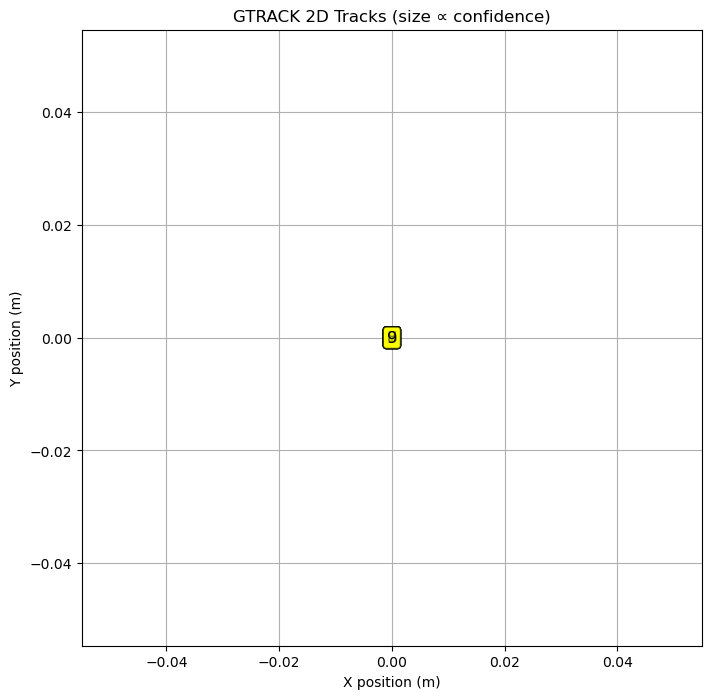

In [522]:
import matplotlib.pyplot as plt

def plot_gtrack(tracks):
    """
    Scatter the current positions of each track, draw a velocity arrow,
    and label by track UID.
    """
    plt.figure(figsize=(8,8))
    for tr in tracks:
        x, y       = tr['pos']
        vx, vy     = tr['vel']
        uid        = tr['uid']
        confidence = tr.get('confidence', 1.0)

        # draw the position
        plt.scatter(x, y, s=100*confidence, edgecolors='k', facecolors='none')
        # draw an arrow showing velocity
        plt.quiver(x, y, vx, vy, angles='xy', scale_units='xy', scale=1, width=0.005)

        # label with the track ID
        plt.text(x, y, f"{uid}", fontsize=12, ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.5))

    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    plt.title("GTRACK 2D Tracks (size ∝ confidence)")
    plt.axis('equal')
    plt.grid(True)
    plt.show()

# Then, somewhere in your loop:
plot_gtrack(output['tracks'])

Apply transform to the data.

In [329]:
# Window hanning
window = np.hanning(radar_params['num_samples'])
adc_windowed = raw_data * window
range_fft = np.fft.fft(adc_windowed) # this is the range FFT of the data

Define the angles and range bins to run, and run the BF algo.

In [209]:
# define the azimuth angles (horizontal FOV) that we want to look at 
r_idxs = np.arange(0, 140)
phi_s, phi_e = 0, 180
phi_res = 1
theta_s, theta_e = 70,110
theta_res = 1

# Run your algorithm here
bf_output1 =  beamform_2d_s(range_fft[:,:,r_idxs], phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_ant_pos, z_pos, r_idxs, radar_params,0, dets)

In [210]:
# Ensure the directory exists
os.makedirs(save_data_path, exist_ok=True)

# Save the output
np.save(save_data_path + "/data_output.npy", bf_output1)

# Save the angles
np.savez(save_data_path +  "/data_angles.npz", phi= phi, theta= theta, r_idxs= r_idxs)

NameError: name 'phi' is not defined

In [ ]:
# Load the output
load_data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/project/data/output/project/beamforming_2d_output/rdc_usejd_thomas_acote_separe'

In [ ]:
# Load the output
bf_output1 = np.load(load_data_path + "/data_output" + ".npy")

# Load the angles
angles = np.load(load_data_path + "/data_angles" + ".npz")
phi = angles['phi']
theta = angles['theta']
r_idxs = angles['r_idxs']

In [ ]:
threshold = np.percentile(bf_output1, 96)
bf_output1 = np.where(bf_output1 > threshold, bf_output1, 0)

In [ ]:
from scipy.ndimage import median_filter

# Median filtering on magnitude:
bf_output1 = median_filter(np.abs(bf_output1), size=(1,1,1))

In [ ]:
# Plot the output from 2D Beamforming (You can change this as you see fit)
fig = plt.figure(figsize=(20, 20))

to_plot = np.sum(abs(bf_output1),axis=1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
output_top = to_plot
ax1 = fig.add_subplot(142,projection = 'polar')
utils.plot_2d_heatmap(ax1, to_plot, phi, r_idxs, vmin=0, vmax=0.1)
ax1.title.set_text('Bird Eye View (Top View)')

plt.tight_layout()
plt.show()

In [ ]:
# Import
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

In [ ]:
# --- Inputs ---
# heatmap: 2D array, shape (azimuth, z)
# phi_array: 1D array of azimuth angles in degrees (length = heatmap.shape[0])
# z_res: resolution along z-axis in meters
# radar_range: estimated mean range to convert angles into lateral meters

# remove close noise
output_top[:, 0:10] = 0

# Build full coordinate grid
phi_rad_2d, r_idxs_2d = np.meshgrid(phi, r_idxs, indexing='ij')  # shape: (180, 140)

x_coords_m = np.sin(phi_rad_2d) * r_idxs_2d  # shape: (180, 140)
z_coords_m = r_idxs_2d  # shape: (180, 140)

# Flatten for DBSCAN
points = np.stack([x_coords_m.ravel(), z_coords_m.ravel()], axis=1)
powers = output_top.ravel()

# Optional: keep only high-power points
threshold = np.percentile(powers, 96)
valid_mask = powers > threshold
points_thresh = points[valid_mask]

# --- DBSCAN ---
db = DBSCAN(eps=2.5, min_samples=90).fit(points_thresh)
labels = db.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Detected {n_clusters} clusters (people).")

In [ ]:
# Plot DBSCAN results
plt.figure(figsize=(6, 6))
output_top.T[:] = 0
plt.imshow(output_top.T, extent=[x_coords_m.min(), x_coords_m.max(), z_coords_m.min(), z_coords_m.max()],
           origin='lower', aspect='auto', cmap='hot')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("DBSCAN Clustering on Full Heatmap")

# Plot clusters
for label in np.unique(labels):
    if label == -1:
        continue  # noise
    cluster_pts = points_thresh[labels == label]
    plt.scatter(cluster_pts[:,0], cluster_pts[:,1], s=30, label=f'Person {label+1}', alpha=0.7)

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Plot Front view
fig = plt.figure(figsize=(7, 7))

to_plot = np.sum(abs(bf_output1[:,:,20:40]),axis=-1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
ax0 = fig.add_subplot()
utils.plot_2d_polar_heatmap(ax0, to_plot, phi, theta, vmin=0, vmax=0.1)
ax0.title.set_text('Front View')

plt.tight_layout()
plt.show()

In [ ]:
# Plot Side view
fig = plt.figure(figsize=(7, 7))

to_plot = np.sum(abs(bf_output1),axis=0)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
ax2 = fig.add_subplot()
utils.plot_2d_heatmap(ax2, to_plot, theta, r_idxs, vmin=0, vmax=0.1)
ax2.title.set_text('Side View')

plt.tight_layout()
plt.show()

In [ ]:
# Plot 3d view
fig = plt.figure(figsize=(7, 7))

to_plot = bf_output1
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
ax3 = fig.add_subplot(projection = '3d')
utils.plot_3d_polar_heatmap(ax3, to_plot, phi, theta, r_idxs, 0.1)
ax3.title.set_text('3d View')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from tqdm import tqdm
from scipy.ndimage import median_filter
import time

# === File Paths ===
data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/project/data/input/data_mat/project/rdc_usejd_marche.mat'
static_data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/Group_2/COM-304-Radars/project/data/input/data_mat/project/rdc_vide_2.mat'

# === Load dynamic signal ===
radar_params, raw_data = utils.load_raw_data(data_path)  # (12, num_frames, 512)

# === FFT both ===
# Window hamming
window = np.hanning(radar_params['num_samples'])
adc_windowed = raw_data * window

# Apply FFT
range_fft = np.fft.fft(adc_windowed)

# === Antenna positions ===
x_ant_pos, z_ant_pos, x_ant = utils.get_ant_pos_2d(
    radar_params['num_x_stp'],
    radar_params['num_z_stp'],
    radar_params['num_rx']
)

# === Beamforming parameters ===
r_idxs = np.arange(0, 140)
phi_s, phi_e, phi_res = 0, 180, 1
theta_s, theta_e, theta_res = 70, 110, 1
phi = np.arange(phi_s, phi_e, phi_res) * np.pi / 180

theta = np.radians(np.arange(theta_s, theta_e, theta_res))
num_frames = radar_params['num_frames']

# === Precompute Beamforming ===
print("⚙️ Precomputing beamformed frames with noise removal...")
bf_frames = []
for i in tqdm(range(500)):
    #frame = beat_freq_super[:, i, r_idxs] # (12, 1, 512)
    bf, _, _ = beamform_2d(
        range_fft[:, :, r_idxs],
        phi_s, phi_e, phi_res,
        theta_s, theta_e, theta_res,
        x_ant_pos, z_ant_pos,
        r_idxs, radar_params, i
    )

    #threshold = np.percentile(bf, 98)
    #bf = np.where(bf > threshold, bf, 0)

    bf = median_filter(np.abs(bf), size=(1,1,1))

    bf = np.sum(abs(bf), axis=1)
    bf= bf/np.max(np.reshape(bf,(1,-1)))
    bf = bf ** 2
    bf_frames.append(bf)  # (phi, range)
# === Create animation ===
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='polar')

def update(frame_idx):
    ax.clear()
    to_plot = bf_frames[frame_idx]
    utils.plot_2d_heatmap(ax, to_plot, phi, r_idxs, vmin=0, vmax=0.1)
    ax.set_title(f'Top View Frame {frame_idx+1}/{num_frames}', va='bottom')
    return ax.collections

ani = animation.FuncAnimation(fig, update, frames=len(bf_frames), interval=50, blit=False)
ani.save("top_view_video_usejd_marche.gif", writer='pillow', fps=20)
plt.close(fig)
print("✅ Saved: top_view_video.gif")